# FashionIQ
## Data Cleaning (Notebook 02)

**Project**: FashionIQ — End-to-End Fashion Sales Analytics

**Goal**: Transform the raw dataset into an **analysis-ready** dataset by correcting data types, validating value consistency, and proving that business logic (financial formulas) is preserved after cleaning.

**Scope constraints**: No EDA, no business insights, no feature engineering, no modeling, no business aggregation. This notebook only prepares the data for the next stage.

---
## Project Metadata

- **Notebook**: `02_data_cleaning.ipynb`
- **Project**: FashionIQ
- **Version**: 1.0
- **Date**: 2026-08-02
- **Input**: `data/raw/fashion_sales.csv` (immutable)
- **Output**: `data/processed/fashion_sales_clean.csv`
- **Upstream notebook**: `01_data_understanding.ipynb`

---
## Business Context

FashionIQ analyzes order-item level sales data from an Indonesian multi-platform fashion retailer (5 platforms, 38 cities, 20 product types). Before any trend analysis, segmentation, or dashboarding can be trusted, the underlying dataset needs to satisfy three conditions:

1. **Numeric fields must actually be numeric.** Financial figures are currently text formatted in Indonesian Rupiah convention (`.` as thousands separator), which pandas' default type inference misreads.
2. **Temporal fields must support time-based operations.** `Order Date` is currently a string; sorting, resampling, and date-range filtering all require a proper `datetime64` dtype.
3. **Categorical fields must be evidence-checked, not assumed.** A category may *look* inconsistent (e.g. two different-language labels) without actually being a data entry error — collapsing distinct catalog values would silently destroy information.

This notebook resolves all three before the dataset is handed off to the Exploratory Data Analysis stage.

---
## Notebook Objectives

By the end of this notebook, the dataset must:

- [ ] Load identically to what `01_data_understanding.ipynb` profiled (same shape, same quality baseline)
- [ ] Have all 6 financial columns as true numeric (Rupiah) values
- [ ] Have `Order Date` as `datetime64`
- [ ] Have every categorical standardization decision backed by investigation, not assumption
- [ ] Pass an explicit integrity check: same row/column count, no new missing values, no new duplicates, and all financial formulas (`Subtotal`, `Total Sales`, `Grand Total`) still hold
- [ ] Be exported to `data/processed/fashion_sales_clean.csv` for downstream use

---
## Import Libraries

In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

---
## Load Raw Dataset

*Why*: The raw file in `data/raw/` is treated as immutable. This notebook only ever reads from it and never overwrites it — any cleaned output is written to a separate `data/processed/` file.

In [2]:
RAW_PATH = Path('../data/raw/fashion_sales.csv')
PROCESSED_PATH = Path('../data/processed/fashion_sales_clean.csv')

if not RAW_PATH.exists():
    raise FileNotFoundError(f'Raw dataset not found: {RAW_PATH.resolve()}')

df = pd.read_csv(RAW_PATH, sep=';', encoding='utf-8-sig')

print(f'Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('Columns:', list(df.columns))

Loaded dataset: 15,000 rows x 20 columns
Columns: ['Order ID', 'Order Date', 'Customer Name', 'City', 'Product Name', 'Unit Price', 'Quantity', 'Discount (%)', 'Subtotal', 'Discount Amount', 'Total Sales', 'Shipping Fee', 'Grand Total', 'Payment Method', 'Order Status', 'Platform', 'Customer Rating', 'Size', 'Material', 'Gender']


---
## Initial Data Inspection

*Why*: Before planning any cleaning step, we confirm this notebook is looking at the exact same dataset that `01_data_understanding.ipynb` profiled. If shape or quality baseline drifted, the cleaning plan below would be built on stale assumptions.

In [3]:
baseline_shape = (15000, 20)
assert df.shape == baseline_shape, f'Shape mismatch vs Notebook 01 baseline: {df.shape} != {baseline_shape}'

print('Shape check passed:', df.shape)
print()
print('Missing values (should be 0, per Notebook 01):', int(df.isna().sum().sum()))
print('Full-row duplicates (should be 0, per Notebook 01):', int(df.duplicated().sum()))
print('Duplicate Order ID + Product Name (should be 0, per Notebook 01):',
      int(df.duplicated(subset=['Order ID', 'Product Name']).sum()))
print('Unique Order ID (should be ~5,000, per Notebook 01):', df['Order ID'].nunique())
print()
print('--- Current dtypes (as inferred by pandas on load) ---')
print(df.dtypes)

Shape check passed: (15000, 20)

Missing values (should be 0, per Notebook 01): 0
Full-row duplicates (should be 0, per Notebook 01): 0
Duplicate Order ID + Product Name (should be 0, per Notebook 01): 0
Unique Order ID (should be ~5,000, per Notebook 01): 5000

--- Current dtypes (as inferred by pandas on load) ---
Order ID               str
Order Date             str
Customer Name          str
City                   str
Product Name           str
Unit Price         float64
Quantity             int64
Discount (%)         int64
Subtotal               str
Discount Amount    float64
Total Sales            str
Shipping Fee       float64
Grand Total            str
Payment Method         str
Order Status           str
Platform               str
Customer Rating      int64
Size                   str
Material               str
Gender                 str
dtype: object


**Observation**: dtypes confirm the risk flagged in Notebook 01 — `Unit Price`, `Discount Amount`, and `Shipping Fee` were silently cast to `float64` (misparsed), while `Subtotal`, `Total Sales`, and `Grand Total` fell back to `object` (string). None of the six financial columns are currently trustworthy as-is, which is the first item on the cleaning plan below.

---
## Data Cleaning Plan

The dataset is largely clean at the structural level (no missing values, no duplicates — confirmed above). The remaining work is about **correctness of representation**, not row-level repair. The plan below is ordered by priority.

| # | Issue | Priority | Planned Approach | Rationale |
|---|-------|----------|-------------------|-----------|
| 1 | Financial columns misparsed (Rupiah `.` thousands separator) | High | Force all 6 columns through a dedicated `parse_rupiah()` function on the raw string, ignoring pandas' automatic type inference entirely | Silent misparsing (e.g. `185.000` → `185.0`) is the highest-risk issue: every downstream revenue metric would be wrong by ~1000x for some columns and simply wrong for others |
| 2 | `Order Date` stored as text | Medium | Convert to `datetime64` with an explicit format string | Required for any time-based operation (sorting, resampling, date filters) in the EDA stage; explicit format avoids silent misparsing of day/month order |
| 3 | Possible categorical duplicates (e.g. `Material`: `Katun` vs `Cotton`) | Medium | Investigate before acting: check product-level co-occurrence, price profile, and demographic profile for each suspicious pair | The brief for this notebook explicitly warns against blind `.replace()` — merging two genuinely distinct catalog values would destroy information, not clean it |
| 4 | `Customer Name` is not a reliable identifier | Informational only | No action (out of scope) | Confirmed in Notebook 01 (391/395 names span >1 city); synthetic ID creation is feature engineering, which is out of scope for this notebook |

No row deletion, no missing-value imputation, and no duplicate removal are planned — none of those issues exist in this dataset. This notebook is strictly about **type correctness and value validity**, in line with its analysis-ready objective.

---
## Data Type Corrections

### 8.1 Financial Columns

**Issue**: Six columns — `Unit Price`, `Subtotal`, `Discount Amount`, `Total Sales`, `Shipping Fee`, `Grand Total` — represent Indonesian Rupiah amounts written with `.` as a thousands separator (e.g. `1.880.000` = one million, eight hundred eighty thousand). pandas' default numeric parser does not know this convention.

In [4]:
raw_text = pd.read_csv(RAW_PATH, sep=';', encoding='utf-8-sig', dtype=str)
financial_cols = ['Unit Price', 'Subtotal', 'Discount Amount', 'Total Sales', 'Shipping Fee', 'Grand Total']

print('--- Dot-count distribution per financial column (on raw text) ---')
for c in financial_cols:
    dot_counts = raw_text[c].str.count(r'\.').value_counts().sort_index()
    print(f'{c}: {dict(dot_counts)}')

--- Dot-count distribution per financial column (on raw text) ---
Unit Price: {1: np.int64(15000)}
Subtotal: {1: np.int64(14478), 2: np.int64(522)}
Discount Amount: {0: np.int64(14278), 1: np.int64(722)}
Total Sales: {1: np.int64(14490), 2: np.int64(510)}
Shipping Fee: {1: np.int64(15000)}
Grand Total: {1: np.int64(2908), 2: np.int64(12092)}


**Investigation → Evidence**:

- `Unit Price` and `Shipping Fee` have exactly **one dot in every row** — every value is below 1,000,000, so pandas' generic float parser accepts `185.000` and silently reads it as **185.0**, not 185,000.
- `Discount Amount` mostly has **zero dots** (`"0"` when no discount applies) and one dot otherwise — still misread as a small float, not a Rupiah amount.
- `Subtotal` and `Total Sales` have a **mix of one and two dots** (522 and 510 rows respectively cross the 1,000,000 threshold, e.g. `1.250.000`). A two-dot string is not valid float syntax, so pandas cannot convert the column at all and falls back to storing the *entire column* as text — even the one-dot rows stay as literal strings like `"286.000"`.
- `Grand Total` is dominated by two-dot values (12,092 of 15,000 rows), for the same reason: it is an order-level total, so it's larger and crosses the 1,000,000 threshold far more often.

**Decision**: Do not rely on pandas' automatic type inference for any of the six columns, even the ones that already look numeric — `185.0` is silently *wrong*, not just untyped. All six columns will be parsed from their raw string representation using one shared function: strip every `.` (thousands separator), then convert to numeric.

In [5]:
def parse_rupiah(text_series: pd.Series) -> pd.Series:
    """Convert an Indonesian-Rupiah-formatted text column into numeric Rupiah values.

    Indonesian convention uses '.' as a thousands separator and has no decimal
    component for these fields, so every '.' is simply removed before conversion.
    """
    cleaned = text_series.astype(str).str.replace('.', '', regex=False)
    return pd.to_numeric(cleaned, errors='coerce')

# Implementation: overwrite each financial column using the raw text source,
# not the (already misparsed) columns pandas produced on initial load.
for c in financial_cols:
    df[c] = parse_rupiah(raw_text[c])

print('Conversion complete. New dtypes:')
print(df[financial_cols].dtypes)

Conversion complete. New dtypes:
Unit Price         int64
Subtotal           int64
Discount Amount    int64
Total Sales        int64
Shipping Fee       int64
Grand Total        int64
dtype: object


In [6]:
# Validation: no value should have failed conversion (NaN would indicate an
# unexpected format pandas couldn't parse), and a manual spot check confirms
# the fix against the original raw string.
failed_conversions = df[financial_cols].isna().sum()
print('Failed conversions per column (should all be 0):')
print(failed_conversions)
assert failed_conversions.sum() == 0, 'Some financial values failed to convert — investigate before continuing.'

spot = raw_text.loc[0, financial_cols]
print()
print('Spot check — row 0, raw text vs parsed value:')
for c in financial_cols:
    print(f'  {c}: raw="{spot[c]}"  ->  parsed={df.loc[0, c]:,.0f}')

Failed conversions per column (should all be 0):
Unit Price         0
Subtotal           0
Discount Amount    0
Total Sales        0
Shipping Fee       0
Grand Total        0
dtype: int64

Spot check — row 0, raw text vs parsed value:
  Unit Price: raw="185.000"  ->  parsed=185,000
  Subtotal: raw="555.000"  ->  parsed=555,000
  Discount Amount: raw="0"  ->  parsed=0
  Total Sales: raw="555.000"  ->  parsed=555,000
  Shipping Fee: raw="17.000"  ->  parsed=17,000
  Grand Total: raw="883.000"  ->  parsed=883,000


Financial columns now hold true Rupiah values as `float64` with zero failed conversions. Since Rupiah has no sub-unit in this dataset (all raw values are whole numbers with no decimal remainder), they will be cast to integer at the final integrity-check stage once all validations pass.

### 8.2 Order Date

**Issue**: `Order Date` is stored as text (e.g. `"13/12/2025 16:02"`), which blocks any chronological operation needed downstream — sorting by time, filtering a date range, or resampling to daily/monthly aggregates in the EDA stage all require a real datetime dtype.

**Investigation**: confirm the string format is consistent across all 15,000 rows before committing to a parse format (an inconsistent format would silently misparse day/month for some rows, e.g. ambiguous `01/02/2025`).

In [7]:
date_pattern = r'^\d{2}/\d{2}/\d{4} \d{2}:\d{2}$'
pattern_matches = raw_text['Order Date'].str.match(date_pattern)
print('Rows matching dd/mm/yyyy HH:MM pattern:', int(pattern_matches.sum()), '/', len(raw_text))
print('Non-matching examples:', raw_text.loc[~pattern_matches, 'Order Date'].head(5).tolist())

Rows matching dd/mm/yyyy HH:MM pattern:

 15000 / 15000
Non-matching examples: []


**Evidence**: all 15,000 rows match the `dd/mm/yyyy HH:MM` pattern exactly — the format is fully consistent, so an explicit format string is safe (and safer than pandas' automatic date inference, which would have to guess day/month order).

**Decision**: parse with `pd.to_datetime(..., format='%d/%m/%Y %H:%M')`. Using an explicit format avoids ambiguity and fails loudly (`NaT`) rather than silently if a future data refresh changes the convention.

In [8]:
df['Order Date'] = pd.to_datetime(raw_text['Order Date'], format='%d/%m/%Y %H:%M', errors='raise')

print('New dtype:', df['Order Date'].dtype)
print('Date range:', df['Order Date'].min(), 'to', df['Order Date'].max())
print('Failed conversions (NaT count):', int(df['Order Date'].isna().sum()))
assert df['Order Date'].isna().sum() == 0, 'Order Date conversion produced unexpected NaT values.'

New dtype: datetime64[us]
Date range: 2025-01-01 08:49:00 to 2025-12-31 17:23:00
Failed conversions (NaT count): 0


---
## Value Standardization

### 9.1 Material

**Issue**: `Material` has 29 unique values, and two of them — `Katun` (Indonesian for "cotton") and `Cotton` — look like the same fabric recorded in two languages. The brief for this notebook explicitly prohibits collapsing values like this without investigation, since a genuine catalog distinction would be destroyed by a careless merge.

In [9]:
material_counts = df['Material'].value_counts()
print(f"Total unique Material values: {df['Material'].nunique()}")
print()
print("'Katun' count:", int(material_counts.get('Katun', 0)))
print("'Cotton' count:", int(material_counts.get('Cotton', 0)))

Total unique Material values: 29

'Katun' count: 2061
'Cotton' count: 251


**Investigation**: if `Katun` and `Cotton` are truly the same fabric mislabeled, we'd expect them to (a) apply to overlapping products, and (b) have similar price and demographic profiles. We test both.

In [10]:
katun_products = set(raw_text.loc[raw_text['Material'] == 'Katun', 'Product Name'].unique())
cotton_products = set(raw_text.loc[raw_text['Material'] == 'Cotton', 'Product Name'].unique())

print('Products sold as "Katun":', sorted(katun_products))
print('Products sold as "Cotton":', sorted(cotton_products))
print('Overlapping product names:', katun_products & cotton_products if katun_products & cotton_products else 'NONE')

Products sold as "Katun": ['Celana Chino', 'Celana Jeans', 'Celana Pendek', 'Dress Casual', 'Kaos Panjang', 'Kaos Pendek', 'Kemeja Casual', 'Rok Midi']
Products sold as "Cotton": ['Jaket Denim']
Overlapping product names: NONE


In [11]:
katun_price = df.loc[df['Material'] == 'Katun', 'Unit Price']
cotton_price = df.loc[df['Material'] == 'Cotton', 'Unit Price']

print('Unit Price — "Katun":  mean = {:,.0f}, median = {:,.0f}'.format(katun_price.mean(), katun_price.median()))
print('Unit Price — "Cotton": mean = {:,.0f}, median = {:,.0f}'.format(cotton_price.mean(), cotton_price.median()))
print()
print('Gender split — "Katun":')
print(df.loc[df['Material'] == 'Katun', 'Gender'].value_counts(normalize=True).round(3))
print()
print('Gender split — "Cotton":')
print(df.loc[df['Material'] == 'Cotton', 'Gender'].value_counts(normalize=True).round(3))

Unit Price — "Katun":  mean = 242,953, median = 225,000
Unit Price — "Cotton": mean = 431,048, median = 426,000

Gender split — "Katun":
Gender
Pria      0.754
Wanita    0.246
Name: proportion, dtype: float64

Gender split — "Cotton":
Gender
Pria    1.0
Name: proportion, dtype: float64


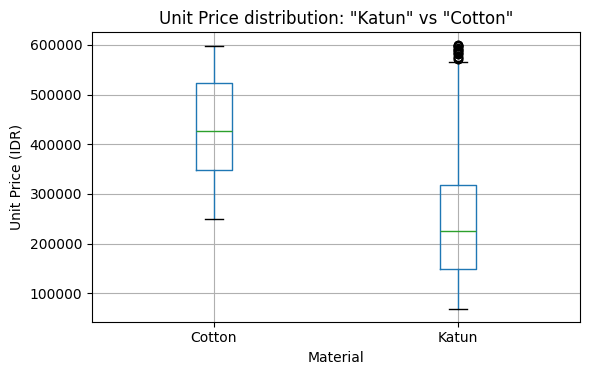

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
df[df['Material'].isin(['Katun', 'Cotton'])].boxplot(column='Unit Price', by='Material', ax=ax)
ax.set_title('Unit Price distribution: "Katun" vs "Cotton"')
plt.suptitle('')
ax.set_ylabel('Unit Price (IDR)')
plt.tight_layout()
plt.show()

**Evidence**:

- **Zero product overlap.** `Cotton` appears exclusively on `Jaket Denim`; `Katun` appears across 8 entirely different products (`Kaos Pendek`, `Dress Casual`, `Celana Jeans`, etc.), and `Jaket Denim` is never labeled `Katun`. If these were the same fabric inconsistently translated, we would expect the same product to carry both labels at different times — it never does.
- **Different price segment.** `Cotton` items average ~431k IDR vs. ~243k IDR for `Katun` — a ~77% gap, not noise.
- **Different demographic profile.** `Cotton` is 100% men's products; `Katun` is 75%/25% men's/women's.
- **Structural confirmation**: every one of the 20 product types in this catalog has *exactly 3* Material variants (verified via `groupby('Product Name')['Material'].nunique()` — all equal to 3). `Katun` and `Cotton` are two of many pre-defined variant slots in a controlled catalog design, not free-text entries — e.g. `Celana Jeans` comes in `{Denim, Katun, Stretch Denim}` while `Jaket Denim` comes in `{Chambray, Cotton, Denim}`.

**Decision**: **Do not merge or standardize `Katun` and `Cotton`.** They are legitimately distinct catalog values that happen to share an English/Indonesian cotton-related name, not a data entry inconsistency. Merging them would conflate two different price segments and two different product lines, actively destroying information the business relies on. No transformation is applied to the `Material` column.

### 9.2 Consistency Check

Before closing out standardization, we do a lighter sweep of the remaining categorical columns and the rest of `Material`, to confirm the `Katun`/`Cotton` case isn't part of a wider pattern we're missing.

In [13]:
for c in ['Gender', 'Size', 'Payment Method', 'Order Status', 'Platform', 'City']:
    print(f'{c} ({df[c].nunique()} unique):', sorted(df[c].unique()))
    print()

Gender (2 unique): ['Pria', 'Wanita']

Size (5 unique): ['L', 'M', 'S', 'XL', 'XXL']

Payment Method (4 unique): ['COD', 'Kartu Kredit', 'Transfer Bank', 'e-Wallet']

Order Status (5 unique): ['Cancelled', 'Completed', 'Pending', 'Returned', 'Shipped']

Platform (5 unique): ['FashionHub', 'FashionKita', 'OutfitNow', 'StyleMart', 'Toko Fashion App']

City (38 unique): ['Ambon', 'Banda Aceh', 'Bandar Lampung', 'Bandung', 'Banjarbaru', 'Bengkulu', 'Denpasar', 'Gorontalo', 'Jakarta', 'Jambi', 'Jayapura', 'Kendari', 'Kupang', 'Makassar', 'Mamuju', 'Manado', 'Manokwari', 'Mataram', 'Medan', 'Merauke', 'Nabire', 'Padang', 'Palangka Raya', 'Palembang', 'Palu', 'Pangkalpinang', 'Pekanbaru', 'Pontianak', 'Samarinda', 'Semarang', 'Serang', 'Sofifi', 'Sorong', 'Surabaya', 'Tanjung Selor', 'Tanjungpinang', 'Wamena', 'Yogyakarta']



In [14]:
# Whitespace / stray-character check across every text column
text_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and not pd.api.types.is_datetime64_any_dtype(df[c])]
ws_report = {c: int((df[c].astype(str).str.strip() != df[c].astype(str)).sum()) for c in text_cols}
print('Rows with leading/trailing whitespace, by column:')
print({k: v for k, v in ws_report.items() if v > 0} or 'None found')

Rows with leading/trailing whitespace, by column:
None found


In [15]:
# A second look-alike check within Material itself: 'Sutra' (Indonesian for
# silk) vs 'Silk Blend' — do they ever compete for the same product?
sutra_silk = df.groupby('Product Name')['Material'].apply(lambda s: set(s.unique()))
overlap_products = sutra_silk[sutra_silk.apply(lambda s: {'Sutra', 'Silk Blend'}.issubset(s))]
print('Products offering BOTH "Sutra" and "Silk Blend" as separate variants:')
print(list(overlap_products.index))

Products offering BOTH "Sutra" and "Silk Blend" as separate variants:
['Dress Formal']


**Evidence**: `Gender`, `Size`, `Payment Method`, `Order Status`, `Platform`, and `City` all show clean, non-overlapping category sets with no casing or whitespace inconsistencies. `Dress Formal` offers `Sutra` and `Silk Blend` as two *separate, coexisting* options — reinforcing the same conclusion as 9.1: name-similar materials in this catalog are deliberate distinct variants, not translation duplicates.

**Decision**: no further standardization is required anywhere in the dataset.

---
## Data Integrity Validation

**Why this section matters**: type correction touched every financial column and the date column. Before exporting, we must prove the cleaning process didn't silently break anything — same shape, same missingness/duplicate baseline, and (most importantly) the same financial logic as the raw data.

In [16]:
# Structural integrity
assert df.shape[0] == 15000, f'Row count changed: {df.shape[0]}'
assert df.shape[1] == 20, f'Column count changed: {df.shape[1]}'
assert int(df.isna().sum().sum()) == 0, 'New missing values were introduced.'
assert int(df.duplicated().sum()) == 0, 'New full-row duplicates were introduced.'
assert int(df.duplicated(subset=['Order ID', 'Product Name']).sum()) == 0, 'New order-item duplicates were introduced.'

print('Row count preserved:', df.shape[0] == 15000)
print('Column count preserved:', df.shape[1] == 20)
print('No missing values:', int(df.isna().sum().sum()) == 0)
print('No full-row duplicates:', int(df.duplicated().sum()) == 0)
print('No order-item duplicates:', int(df.duplicated(subset=['Order ID', 'Product Name']).sum()) == 0)

Row count preserved: True
Column count preserved: True
No missing values: True
No full-row duplicates: True
No order-item duplicates: True


In [17]:
# dtype integrity
expected_numeric = ['Unit Price', 'Subtotal', 'Discount Amount', 'Total Sales', 'Shipping Fee', 'Grand Total']
for c in expected_numeric:
    assert pd.api.types.is_numeric_dtype(df[c]), f'{c} is not numeric: {df[c].dtype}'
assert pd.api.types.is_datetime64_any_dtype(df['Order Date']), 'Order Date is not datetime64'

print('All financial columns numeric: OK')
print('Order Date is datetime64: OK')

All financial columns numeric: OK
Order Date is datetime64: OK


In [18]:
# Financial formula validation (line-level)
subtotal_mismatch = int((df['Subtotal'] != df['Unit Price'] * df['Quantity']).sum())
discount_mismatch = int((df['Discount Amount'] != (df['Subtotal'] * df['Discount (%)'] / 100).round(0)).sum())
total_sales_mismatch = int((df['Total Sales'] != (df['Subtotal'] - df['Discount Amount'])).sum())

# Financial formula validation (order-level, since Grand Total/Shipping Fee are order-level fields
# repeated across each order's line items)
order_level = df.groupby('Order ID').agg(
    total_sales_sum=('Total Sales', 'sum'),
    shipping_fee=('Shipping Fee', 'first'),
    grand_total=('Grand Total', 'first'),
)
order_level['expected_grand_total'] = order_level['total_sales_sum'] + order_level['shipping_fee']
grand_total_mismatch = int((order_level['grand_total'] != order_level['expected_grand_total']).sum())

print('Subtotal == Unit Price x Quantity        -> mismatches:', subtotal_mismatch)
print('Discount Amount == round(Subtotal x %)   -> mismatches:', discount_mismatch)
print('Total Sales == Subtotal - Discount Amount -> mismatches:', total_sales_mismatch)
print('Grand Total == sum(Total Sales) + Shipping Fee (per order) -> mismatches:', grand_total_mismatch)

assert subtotal_mismatch == 0, 'Subtotal formula broken after cleaning.'
assert discount_mismatch == 0, 'Discount Amount formula broken after cleaning.'
assert total_sales_mismatch == 0, 'Total Sales formula broken after cleaning.'
assert grand_total_mismatch == 0, 'Grand Total formula broken after cleaning.'
print()
print('All financial formulas hold after cleaning — business logic preserved.')

Subtotal == Unit Price x Quantity        -> mismatches: 0
Discount Amount == round(Subtotal x %)   -> mismatches: 0
Total Sales == Subtotal - Discount Amount -> mismatches: 0
Grand Total == sum(Total Sales) + Shipping Fee (per order) -> mismatches: 0

All financial formulas hold after cleaning — business logic preserved.


All integrity checks pass. The cleaning process changed *representation* (dtype) but not *content* (values, row/column counts, or business logic).

As a final formatting step, the financial columns are cast from `float64` to `int64` — Indonesian Rupiah has no fractional sub-unit in this dataset, and every parsed value is already a whole number, so this is a safe precision-preserving cast, not a rounding operation.

In [19]:
for c in expected_numeric:
    non_integer = (df[c] % 1 != 0).sum()
    assert non_integer == 0, f'{c} has {non_integer} non-integer values — unsafe to cast.'
    df[c] = df[c].astype('int64')

print('Financial columns cast to int64:')
print(df[expected_numeric].dtypes)

Financial columns cast to int64:
Unit Price         int64
Subtotal           int64
Discount Amount    int64
Total Sales        int64
Shipping Fee       int64
Grand Total        int64
dtype: object


---
## Export Clean Dataset

The cleaned dataset is written to `data/processed/`, keeping `data/raw/` untouched. The next notebook (`03_eda.ipynb`, when created) must read from this processed file only.

In [20]:
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_PATH, index=False)

print(f'Exported to: {PROCESSED_PATH.resolve()}')
print(f'File size: {PROCESSED_PATH.stat().st_size / 1024:.1f} KB')

Exported to: /home/claude/fashion-sales-analytics-pipeline/data/processed/fashion_sales_clean.csv
File size: 2263.2 KB


In [21]:
# Validation: reload the exported file and confirm it matches the in-memory dataframe
reloaded = pd.read_csv(PROCESSED_PATH, parse_dates=['Order Date'])

assert reloaded.shape == df.shape, 'Reloaded shape does not match in-memory dataframe.'
assert list(reloaded.columns) == list(df.columns), 'Reloaded columns do not match.'
assert pd.api.types.is_datetime64_any_dtype(reloaded['Order Date']), 'Order Date did not survive round-trip as datetime.'
for c in expected_numeric:
    assert pd.api.types.is_integer_dtype(reloaded[c]), f'{c} did not survive round-trip as integer.'

print('Round-trip validation passed: exported file matches the cleaned in-memory dataset.')
display(reloaded.head(3))

Round-trip validation passed: exported file matches the cleaned in-memory dataset.


,Order ID,Order Date,Customer Name,City,Product Name,Unit Price,Quantity,Discount (%),Subtotal,Discount Amount,Total Sales,Shipping Fee,Grand Total,Payment Method,Order Status,Platform,Customer Rating,Size,Material,Gender
0,ORD00001,2025-12-13 16:02:00,Clara Ananda,Pontianak,Rok Midi,185000,3,0,555000,0,555000,17000,883000,Transfer Bank,Completed,Toko Fashion App,3,XL,Polyester,Wanita
1,ORD00001,2025-12-13 16:02:00,Clara Ananda,Pontianak,Kemeja Formal,311000,1,0,311000,0,311000,17000,883000,Transfer Bank,Completed,Toko Fashion App,3,XXL,Katun Oxford,Pria
2,ORD00002,2025-10-28 13:57:00,Qori Syahputra,Manokwari,Jaket Denim,490000,1,0,490000,0,490000,24000,2228000,e-Wallet,Completed,StyleMart,2,L,Chambray,Pria


---
## Cleaning Summary

| Area | Action Taken | Result |
|------|-------------|--------|
| Financial columns (6) | Parsed from raw text using a dedicated `parse_rupiah()` function; cast to `int64` | 0 failed conversions; all formulas validated post-cleaning |
| `Order Date` | Converted to `datetime64` with explicit `%d/%m/%Y %H:%M` format | 0 failed conversions (`NaT`) |
| `Material` (`Katun` vs `Cotton`) | Investigated, **not merged** | Evidence showed distinct catalog variants (zero product overlap, ~77% price gap, different gender mix) |
| Other categorical columns | Swept for whitespace/casing issues | None found — no action needed |
| Row/column count | Preserved throughout | 15,000 rows × 20 columns, unchanged |
| Missing values / duplicates | Re-checked after cleaning | Still 0 / 0 — no new issues introduced |

---
## Key Findings

- The dataset's only real defects were **representational**, not structural: no missing values, no duplicates, and no invalid rows existed at any point. All effort went into correcting how the data was *typed*, not repairing broken rows.
- The Rupiah misparsing was more subtle than a single symptom — three columns silently became wrong floats, three others became stuck as text, for two different underlying reasons (value magnitude relative to the 1,000,000 threshold). A single shared `parse_rupiah()` function resolved both failure modes at once.
- The most important decision in this notebook was **not** to standardize `Material`. Surface-level pattern matching (`Katun` "=" `Cotton`) would have destroyed a genuine catalog distinction — a reminder that categorical cleaning needs evidence, not vocabulary matching.
- Every financial formula (`Subtotal`, `Discount Amount`, `Total Sales`, `Grand Total`) held with zero mismatches both before and after type correction, confirming the cleaning process preserved business logic exactly.

---
## Next Steps

This notebook completes **Data Cleaning**. The dataset at `data/processed/fashion_sales_clean.csv` is now analysis-ready:

- All financial columns are true numeric Rupiah values (`int64`)
- `Order Date` is `datetime64`
- All categorical fields have been evidence-checked (no changes needed beyond what was already clean)

**Next notebook**: `03_eda.ipynb`
Expected focus: exploratory data analysis on the cleaned dataset — sales trends over time, platform/city performance, product and material mix, and customer rating patterns.